In [ ]:
!gdown --id 1A_EE7CIltvI5YfP_EPzmQ5jeNezT7cfF

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1A_EE7CIltvI5YfP_EPzmQ5jeNezT7cfF
To: /content/transactions.csv
100% 16.1M/16.1M [00:00<00:00, 46.4MB/s]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
# Read data

df = pd.read_csv("/content/transactions.csv", index_col= 0 )

In [ ]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.00,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.00,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.00,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.00,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...
199995,13,CASH_IN,149024.27,C1446913085,8688.0,157712.27,C476402209,440028.59,321427.51,0
199996,13,PAYMENT,71076.01,C1421983410,50291.0,0.00,M855368711,0.00,0.00,0
199997,13,CASH_OUT,147125.05,C80624764,0.0,0.00,C747330421,1058502.64,1325544.47,0
199998,13,CASH_OUT,97529.67,C595001108,0.0,0.00,C575555170,1921846.97,2019376.64,0


In [ ]:
df = df.drop(columns = ['step'])
df

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.00,0.00,0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.00,0.00,0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.00,0.00,1
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.00,0.00,1
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...
199995,CASH_IN,149024.27,C1446913085,8688.0,157712.27,C476402209,440028.59,321427.51,0
199996,PAYMENT,71076.01,C1421983410,50291.0,0.00,M855368711,0.00,0.00,0
199997,CASH_OUT,147125.05,C80624764,0.0,0.00,C747330421,1058502.64,1325544.47,0
199998,CASH_OUT,97529.67,C595001108,0.0,0.00,C575555170,1921846.97,2019376.64,0


In [ ]:
nulls = df.isnull().sum(axis=0).sort_values(ascending=False);
nulls

,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
amount_properties = df['amount'].describe()
print(amount_properties)

count    2.000000e+05
mean     1.808112e+05
std      3.291800e+05
min      3.200000e-01
25%      1.201612e+04
50%      6.872104e+04
75%      2.290791e+05
max      1.000000e+07
Name: amount, dtype: float64


In [ ]:
fraud_counts = df['isFraud'].value_counts()
fraud_ratio = fraud_counts[1] / fraud_counts[0]
print(fraud_counts)
print(f"Fraud / Non-Fraud Ratio: {fraud_ratio:.5f}")

isFraud
0    199853
1       147
Name: count, dtype: int64
Fraud / Non-Fraud Ratio: 0.00074


# **1.4(a): Balance an imbalanced dataset**

<Axes: xlabel='isFraud'>

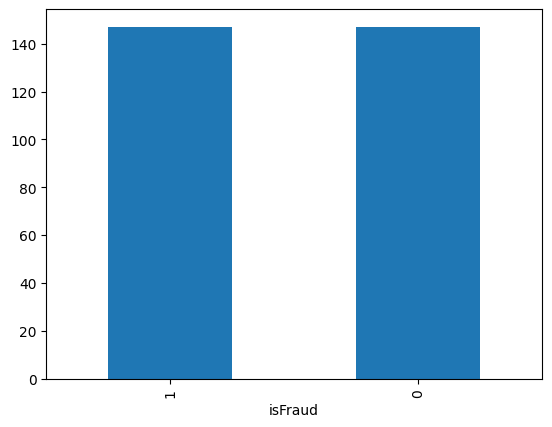

In [ ]:
fraud = df[df["isFraud"] == 1]
non_fraud = df[df["isFraud"] == 0]

non_fraud_sample = non_fraud.sample(len(fraud))
non_fraud_sample.reset_index(drop=True, inplace=True)
fraud.reset_index(drop=True, inplace=True)

balanced_df = pd.concat([fraud, non_fraud_sample]).reset_index(drop=True)
balanced_df['isFraud'].value_counts().plot(kind='bar')

# **1.4(b): Correlation heatmap**

In [ ]:
numeric_features = balanced_df.select_dtypes(include=["int64","float64"])

<Axes: title={'center': 'Correlation matrix of sub-sampled data'}>

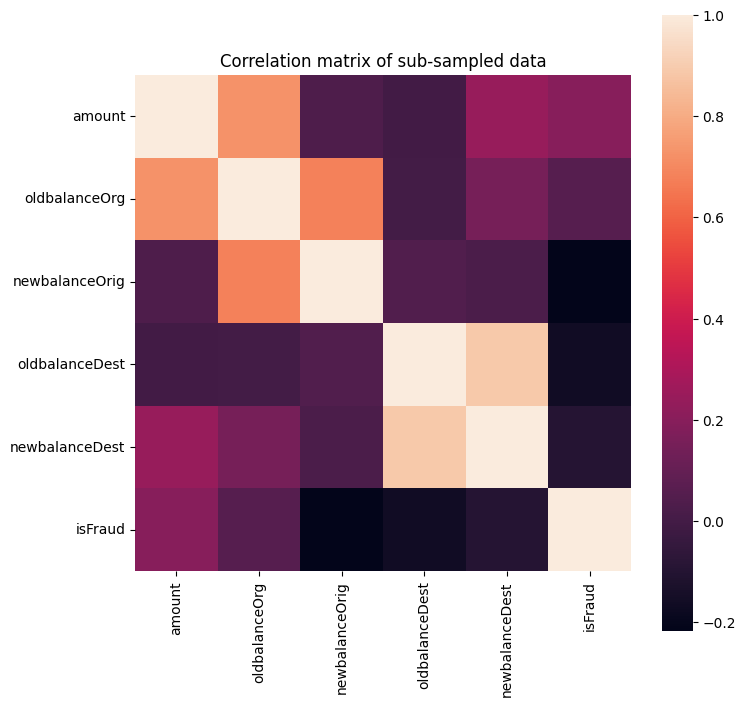

In [ ]:
corrmat = numeric_features.corr()
f, ax = plt.subplots(figsize=(8, 8))
plt.title('Correlation matrix of sub-sampled data')
sns.heatmap(corrmat, vmax=1, square=True)

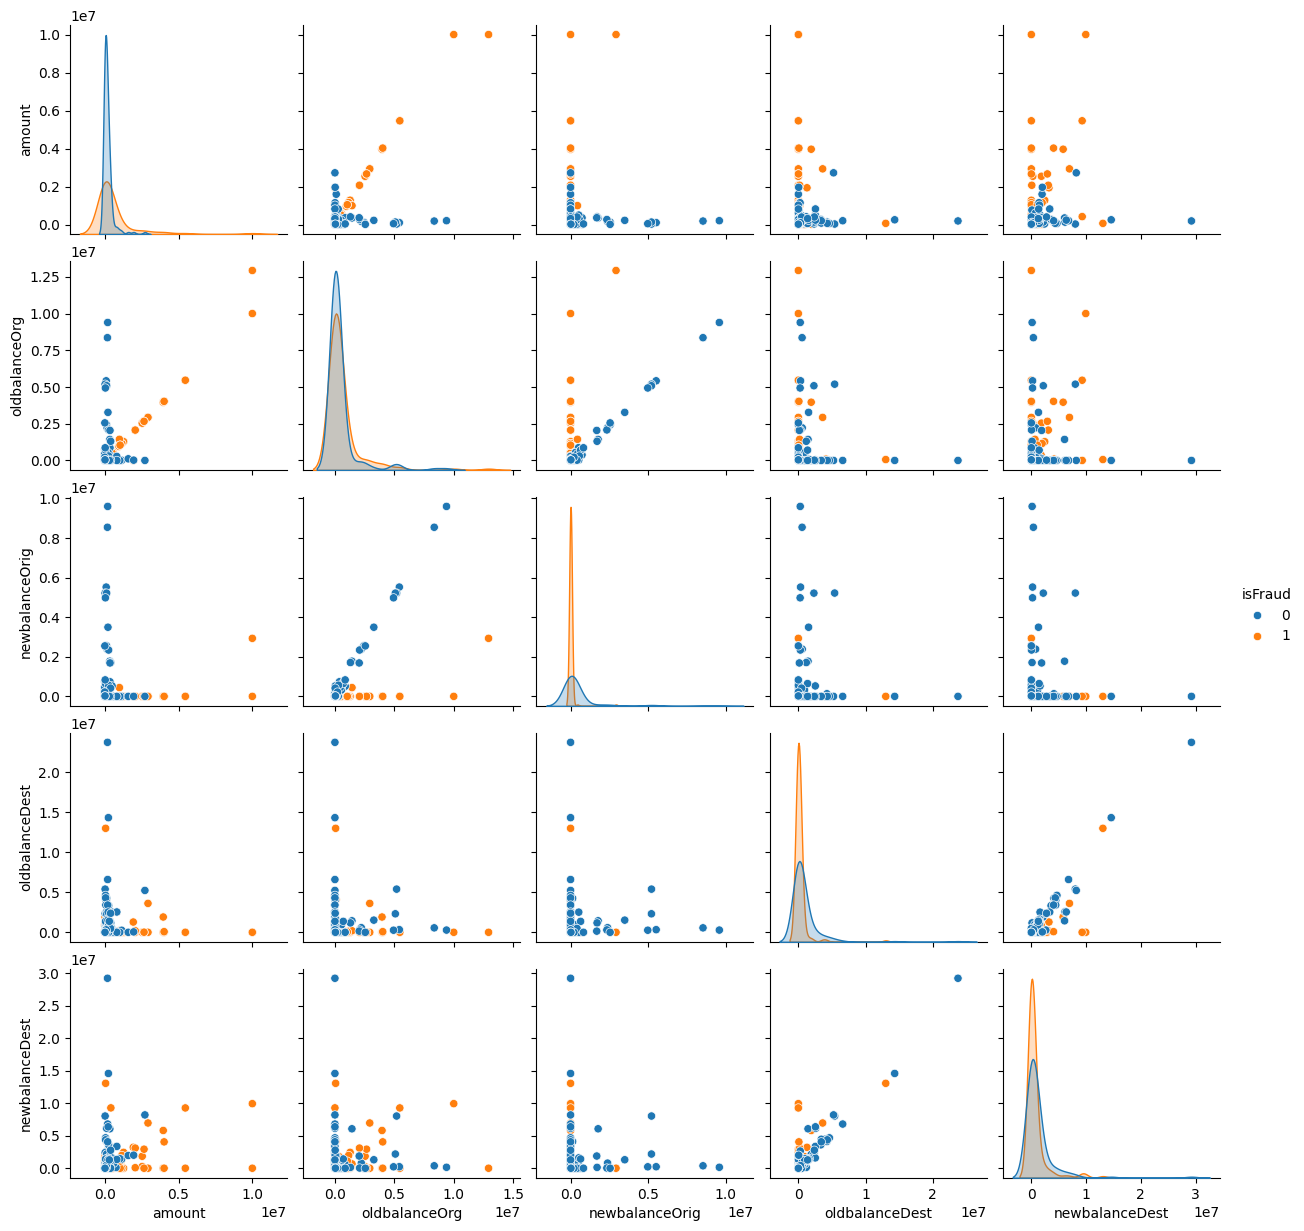

In [ ]:
sns.pairplot(numeric_features, hue="isFraud")
plt.show()

In [ ]:
balanced_df['orig_balance_diff'] = balanced_df['oldbalanceOrg'] - balanced_df['newbalanceOrig']
balanced_df['dest_balance_diff'] = balanced_df['oldbalanceDest'] - balanced_df['newbalanceDest']
balanced_df

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,orig_balance_diff,dest_balance_diff
0,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.00,0.00,1,181.00,0.00
1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.00,0.00,1,181.00,21182.00
2,TRANSFER,2806.00,C1420196421,2806.0,0.00,C972765878,0.00,0.00,1,2806.00,0.00
3,CASH_OUT,2806.00,C2101527076,2806.0,0.00,C1007251739,26202.00,0.00,1,2806.00,26202.00
4,TRANSFER,20128.00,C137533655,20128.0,0.00,C1848415041,0.00,0.00,1,20128.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...
289,TRANSFER,98417.04,C97555480,0.0,0.00,C52581537,306878.98,405296.02,0,0.00,-98417.04
290,CASH_OUT,310700.74,C1927352891,0.0,0.00,C1986543926,1375560.52,1281245.77,0,0.00,94314.75
291,PAYMENT,13231.01,C491209622,224.0,0.00,M454884662,0.00,0.00,0,224.00,0.00
292,PAYMENT,8446.35,C366267503,32074.9,23628.55,M740446920,0.00,0.00,0,8446.35,0.00


In [ ]:
df_encoded = pd.get_dummies(
    balanced_df,
    columns=["type"],
    drop_first=True
)

In [ ]:
df_encoded

,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,orig_balance_diff,dest_balance_diff,type_CASH_OUT,type_PAYMENT,type_TRANSFER
0,181.00,C1305486145,181.0,0.00,C553264065,0.00,0.00,1,181.00,0.00,False,False,True
1,181.00,C840083671,181.0,0.00,C38997010,21182.00,0.00,1,181.00,21182.00,True,False,False
2,2806.00,C1420196421,2806.0,0.00,C972765878,0.00,0.00,1,2806.00,0.00,False,False,True
3,2806.00,C2101527076,2806.0,0.00,C1007251739,26202.00,0.00,1,2806.00,26202.00,True,False,False
4,20128.00,C137533655,20128.0,0.00,C1848415041,0.00,0.00,1,20128.00,0.00,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,98417.04,C97555480,0.0,0.00,C52581537,306878.98,405296.02,0,0.00,-98417.04,False,False,True
290,310700.74,C1927352891,0.0,0.00,C1986543926,1375560.52,1281245.77,0,0.00,94314.75,True,False,False
291,13231.01,C491209622,224.0,0.00,M454884662,0.00,0.00,0,224.00,0.00,False,True,False
292,8446.35,C366267503,32074.9,23628.55,M740446920,0.00,0.00,0,8446.35,0.00,False,True,False


In [ ]:
df_encoded = df_encoded.drop(columns=["nameOrig","nameDest"])

In [ ]:
df_encoded

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_diff,dest_balance_diff,type_CASH_OUT,type_PAYMENT,type_TRANSFER
0,181.00,181.0,0.00,0.00,0.00,1,181.00,0.00,False,False,True
1,181.00,181.0,0.00,21182.00,0.00,1,181.00,21182.00,True,False,False
2,2806.00,2806.0,0.00,0.00,0.00,1,2806.00,0.00,False,False,True
3,2806.00,2806.0,0.00,26202.00,0.00,1,2806.00,26202.00,True,False,False
4,20128.00,20128.0,0.00,0.00,0.00,1,20128.00,0.00,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
289,98417.04,0.0,0.00,306878.98,405296.02,0,0.00,-98417.04,False,False,True
290,310700.74,0.0,0.00,1375560.52,1281245.77,0,0.00,94314.75,True,False,False
291,13231.01,224.0,0.00,0.00,0.00,0,224.00,0.00,False,True,False
292,8446.35,32074.9,23628.55,0.00,0.00,0,8446.35,0.00,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("isFraud", axis=1)
y = df_encoded["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(205, 10)
(205,)
(89, 10)
(89,)


In [ ]:
y_test

,isFraud
33,1
9,1
146,1
282,0
261,0
...,...
265,0
67,1
202,0
165,0


# **1.8: Create decision tree classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)

In [ ]:
result = pd.DataFrame({'actual':y_test, 'predicted':y_pred})
result[result['actual']==1]

,actual,predicted
33,1,1
9,1,1
146,1,1
125,1,1
108,1,0
109,1,1
42,1,1
82,1,1
46,1,1
56,1,1


In [ ]:
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85        39
           1       0.90      0.86      0.88        50

    accuracy                           0.87        89
   macro avg       0.86      0.87      0.86        89
weighted avg       0.87      0.87      0.87        89



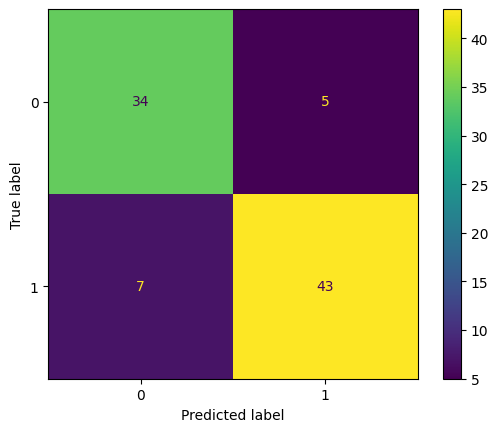

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model_tree, X_test, y_test)

# **1.10 Feature importance**

In [ ]:
fi = pd.DataFrame({'features':X_train.columns,'importance':model_tree.feature_importances_}).sort_values(by=['importance'], ascending=False)
fi

,features,importance
5,orig_balance_diff,0.346811
0,amount,0.231410
4,newbalanceDest,0.143057
8,type_PAYMENT,0.089152
2,newbalanceOrig,0.088784
9,type_TRANSFER,0.034840
6,dest_balance_diff,0.029787
1,oldbalanceOrg,0.019569
3,oldbalanceDest,0.016590
7,type_CASH_OUT,0.000000


<Axes: xlabel='importance', ylabel='features'>

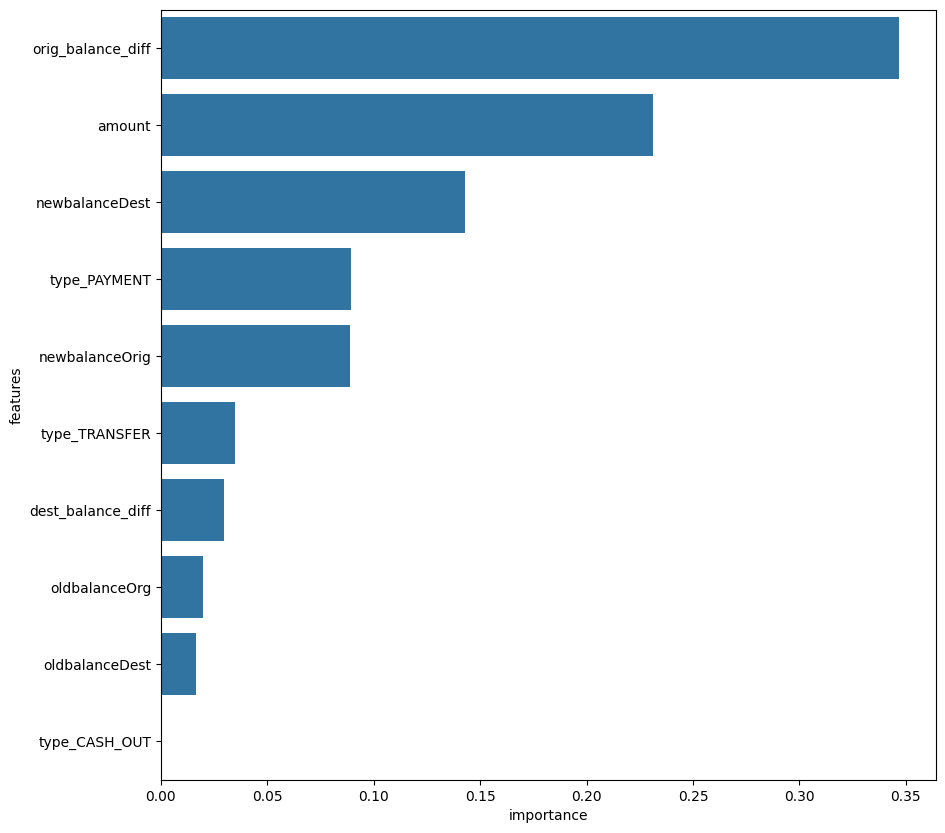

In [ ]:
plt.figure(figsize=(10,10))

sns.barplot(x="importance", y="features", data=fi)